# Modelos de regresión en Machine Learning con Python

**Mayo 2026 · Bloque II**

## Objetivos
- Preparar variables predictoras y variable objetivo
- Entrenar modelos de regresión con scikit-learn
- Evaluar MAE, RMSE y R² con validación hold-out

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Dataset y partición train/test

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(DATA_DIR / "ventas_mayo2026.csv", parse_dates=["fecha"])
df["canal"] = df["canal"].fillna("desconocido")
df["ventas"] = df["ventas"].fillna(df["ventas"].median())
df["dia_semana"] = df["fecha"].dt.dayofweek
X = df[["region","canal","clientes","visitas","inversion_marketing","dia_semana"]]
y = df["ventas"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
X_train.head()

,region,canal,clientes,visitas,inversion_marketing,dia_semana
132,Este,web,39,685,301.59,1
90,Sur,web,40,755,390.08,1
38,Centro,tienda,45,723,417.08,5
169,Este,web,42,676,614.62,3
115,Oeste,web,37,701,419.83,5


## Pipeline de preprocesado + regresión lineal

In [15]:
num_cols = ["clientes","visitas","inversion_marketing","dia_semana"]
cat_cols = ["region","canal"]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

lin_model = Pipeline([("pre", pre), ("model", LinearRegression())])
lin_model.fit(X_train, y_train)
pred = lin_model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", round(r2_score(y_test, pred), 3))

MAE: 231.54
RMSE: 283.12124297310044
R2: 0.425


## Comparación con Random Forest

In [16]:
rf_model = Pipeline([
    ("pre", pre),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

# métricas linear (ya calculadas antes)
mae_lr = mean_absolute_error(y_test, pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred))
r2_lr = r2_score(y_test, pred)

# métricas random forest
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

metrics = pd.DataFrame({
    "modelo": ["LinearRegression", "RandomForestRegressor"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

display(metrics.round(3))

,modelo,MAE,RMSE,R2
0,LinearRegression,231.544,283.121,0.425
1,RandomForestRegressor,265.468,328.247,0.227


## Interpretación de errores

,real,predicho,error
125,2568.52,1678.072267,890.447733
68,938.78,1724.419667,-785.639667
145,1728.25,2376.507600,-648.257600
24,2642.06,2030.449700,611.610300
60,1989.25,1427.074067,562.175933
15,1324.18,1806.610400,-482.430400
65,1833.92,1370.463500,463.456500
100,1382.21,1799.688967,-417.478967
12,2172.39,1787.015133,385.374867
126,1853.86,2222.941867,-369.081867


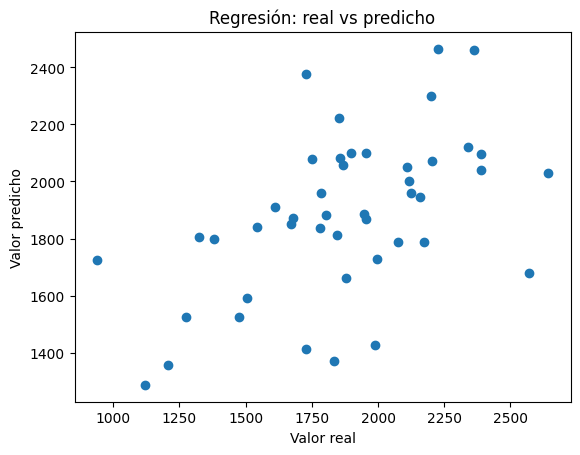

In [17]:
errores = pd.DataFrame({"real": y_test, "predicho": pred_rf})
errores["error"] = errores["real"] - errores["predicho"]
display(errores.sort_values("error", key=abs, ascending=False).head(10))

plt.scatter(errores["real"], errores["predicho"])
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión: real vs predicho")
plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.